In [598]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pandas as pd
import numpy as np
import math 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [599]:
bit = pd.read_csv("./csv/coin_Bitcoin.csv", sep=",")
bit

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.000000e+00,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.000000e+00,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.000000e+00,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.000000e+00,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.000000e+00,1.085995e+09
...,...,...,...,...,...,...,...,...,...,...
2986,2987,Bitcoin,BTC,2021-07-02 23:59:59,33939.588699,32770.680780,33549.600177,33897.048590,3.872897e+10,6.354508e+11
2987,2988,Bitcoin,BTC,2021-07-03 23:59:59,34909.259899,33402.696536,33854.421362,34668.548402,2.438396e+10,6.499397e+11
2988,2989,Bitcoin,BTC,2021-07-04 23:59:59,35937.567147,34396.477458,34665.564866,35287.779766,2.492431e+10,6.615748e+11
2989,2990,Bitcoin,BTC,2021-07-05 23:59:59,35284.344430,33213.661034,35284.344430,33746.002456,2.672155e+10,6.326962e+11


Tratamento de dados da nossa tabela de Bitcoin:

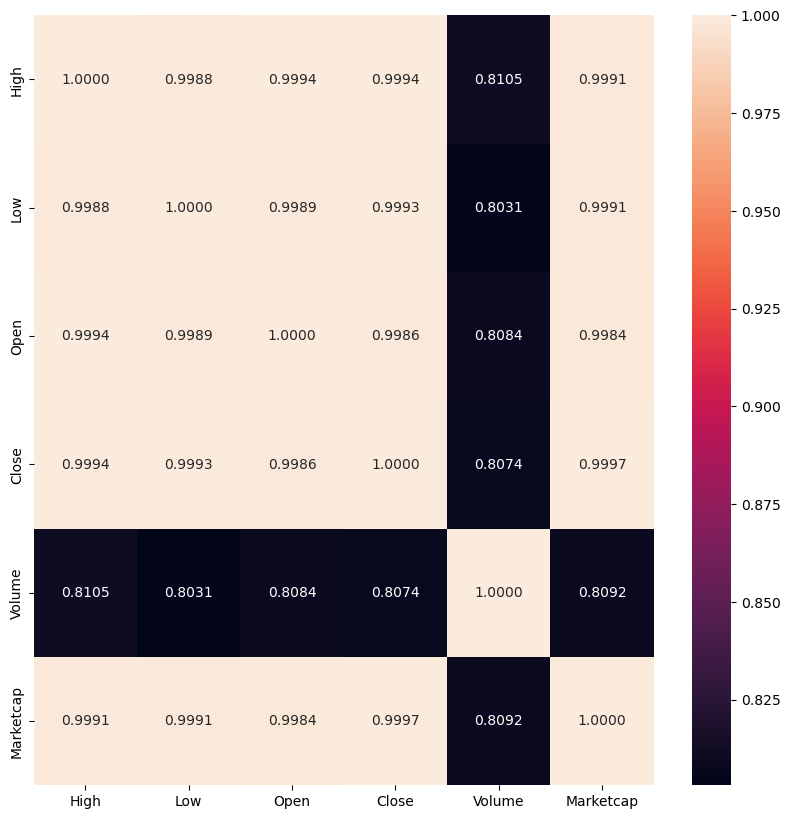

In [600]:
bit.drop('SNo', axis=1, inplace=True) #Index Column
bit.drop('Name', axis=1, inplace=True) #Bitcoin
bit.drop('Symbol', axis=1, inplace=True) #BTC
bit.drop('Date', axis=1, inplace=True) #Date Column

figura = plt.figure(figsize=(10,10)) #tamanho da figura
sns.heatmap(bit.corr(), annot=True, fmt=".4f")  #corr >> correlação; annot >> legenda 
plt.show()

In [601]:
x = bit.loc[:,['Close', 'Open', 'Marketcap', 'High', 'Low']]
y = bit['Volume']

regLinear = []
regPolinomial = []
regRandomForest = []

# score = np.corrcoef(x, y)[0][1]
# score

# correlacao = x.corr(y)
# correlacao

biX = x.values #.reshape(-1, 1)
biX.shape

x_treino, x_teste, y_treino, y_teste = train_test_split(biX, y.values, test_size=0.2, random_state=42)

Regressão Linear

In [602]:
regressorBitcoin = LinearRegression()
regressorBitcoin.fit(x_treino, y_treino)

regLinear.append(regressorBitcoin.score(x_treino, y_treino))
regLinear.append(regressorBitcoin.score(x_teste, y_teste))

previsoes = regressorBitcoin.predict(biX)

# print(previsoes)

# MAE = mean_absolute_error(y_teste, previsoes)
# MSE = mean_squared_error(y_teste, previsoes)
# RMSE = np.sqrt(MSE)

# regLinear.append(MAE, MSE, RMSE)

print(regLinear)

[0.6826684143377482, 0.6903840402842256]


Regressão Linear + Polinomial

In [603]:
poly = PolynomialFeatures(degree=2)

x_treino_poly = poly.fit_transform(x_treino)
x_teste_poly = poly.transform(x_teste)

regressorBitcoin = LinearRegression()
regressorBitcoin.fit(x_treino_poly, y_treino)

regPolinomial.append(regressorBitcoin.score(x_treino_poly, y_treino))
regPolinomial.append(regressorBitcoin.score(x_teste_poly, y_teste))

previsoes = regressorBitcoin.predict(x_teste_poly)

print(regPolinomial)

[0.746209505796851, 0.7737914854039962]


Regressão Random Forest

In [604]:
regressorBitcoin = RandomForestRegressor(n_estimators=100)
regressorBitcoin.fit(x_treino, y_treino)

regRandomForest.append(regressorBitcoin.score(x_treino, y_treino))
regRandomForest.append(regressorBitcoin.score(x_teste, y_teste))

previsoes = regressorBitcoin.predict(x_teste)

print(regRandomForest)

[0.9729955445848488, 0.8888673541963016]


In [610]:
print("-="*30)
print(f"-=-=-REGRESSÃO LINEAR-=-=-\nValor de Treino: {round(regLinear[0]*100, 2)}%\nValor de Teste: {round(regLinear[1]*100, 2)}%\n")
print(f"-=-=-REGRESSÃO POLINOMIAL-=-=-\nValor de Treino: {round(regPolinomial[0]*100, 2)}%\nValor de Teste: {round(regPolinomial[1]*100, 2)}%\n")
print(f"-=-=-REGRESSÃO RANDOM FOREST-=-=-\nValor de Treino: {round(regRandomForest[0]*100, 2)}%\nValor de Teste: {round(regRandomForest[1]*100, 2)}%\n")

-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
-=-=-REGRESSÃO LINEAR-=-=-
Valor de Treino: 68.27%
Valor de Teste: 69.04%

-=-=-REGRESSÃO POLINOMIAL-=-=-
Valor de Treino: 74.62%
Valor de Teste: 77.38%

-=-=-REGRESSÃO RANDOM FOREST-=-=-
Valor de Treino: 97.3%
Valor de Teste: 88.89%



In [605]:
regressorBitcoin.intercept_

AttributeError: 'RandomForestRegressor' object has no attribute 'intercept_'

In [ ]:
regressorBitcoin.coef_

array([ 0.00000000e+00,  7.44392108e-06,  7.82878230e-09,  1.46669688e-01,
        8.01728667e-09,  7.64503423e-09, -8.55252854e-08, -6.89848660e-08,
       -3.93749485e-05, -1.23101717e-07, -1.31446784e-08, -2.87422341e-07,
        2.08452471e-06, -2.88916820e-07,  7.50706960e-09,  2.10017611e-12,
        3.76913001e-06, -7.59983264e-06, -2.63021355e-07, -6.26678016e-08,
        1.65086422e-09])

In [ ]:
previsoes = regressorBitcoin.predict(biX)
previsoes

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       3.26877748e+10, 3.46415705e+10, 3.44753644e+10])

In [ ]:
grafico = px.scatter(x = biX.ravel(), y = y)
grafico.add_scatter(x = biX.ravel(), y = previsoes, name = 'Regressão')
grafico.show()

ValueError: All arguments should have the same length. The length of argument `y` is 2991, whereas the length of  previously-processed arguments ['x'] is 14955

In [ ]:
previsao = regressorBitcoin.predict([[70000]])
print(f"A previsão de quantidades negociadas no dia são de {previsao[0]:.2f}")

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 3)